# Extracting and Visualizing Stock Data

# Description

*Extracting essential data from a dataset and displaying it is a necessary part of data science; therefore individuals can make correct decisions based on the data. In this assignment, you will extract some stock data, you will then display this data in a graph.*

# Table of Contents

1. Define a Function that Makes a Graph
2. Use yfinance to Extract Stock Data
3. Use Webscraping to Extract Tesla Revenue Data
4. Use yfinance to Extract Stock Data
5. Use Webscraping to Extract GME Revenue Data
6. Plot Tesla Stock Graph
7. Plot GameStop Stock Graph

In [1]:
# Install all the required libraries.

!pip install yfinance
!pip install matplotlib
!pip install bs4
!pip install nbformat

In [4]:
# Import the required libarries

import yfinance as yf
import requests
import pandas as pd
from bs4 import BeautifulSoup

In [7]:
#Ignore the warnings

import warnings
warnings.filterwarnings('ignore',category=FutureWarning)


# Define Graphing Function

*In this section, we define the function make_graph. You don't have to know how the function works, you should only care about the inputs. It takes a dataframe with stock data (dataframe must contain Date and Close columns), a dataframe with revenue data (dataframe must contain Date and Revenue columns), and the name of the stock.*

In [67]:
import matplotlib.pyplot as plt
import pandas as pd

def make_graph(stock_data, revenue_data, stock):

    #Convert Date Coloumn Safely
    stock_data["Date"]=pd.to_datetime(stock_data["Date"], errors='coerce')
    revenue_data["Date"]=pd.to_datetime(revenue_data["Date"], errors='coerce')

    #Drop Missing Data
    stock_data= stock_data.dropna(subset= ["Date"])
    revenue_data= revenue_data.dropna(subset = ["Date"])

    #Convert to Numeric
    stock_data["Close"]= stock_data["Close"].astype("float")
    revenue_data["Revenue"]= pd.to_numeric(revenue_data["Revenue"], errors='coerce')

    #Drop missing Revenue
    revenue_data= revenue_data.dropna(subset= ["Revenue"])

    #Apply filter
    stock_data_specific = stock_data[stock_data["Date"] <= '2021-06-14']
    revenue_data_specific = revenue_data[revenue_data["Date"] <= '2021-04-30']

    #plot
    fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

    # Stock Price:
    axes[0].plot(stock_data_specific["Date"], stock_data_specific["Close"], label="Share Price", color='blue')
    axes[0].set_ylabel("price($us)")
    axes[0].set_title(f"{stock} - Historical Share Price")

    #Revenue Price
    axes[1].plot(revenue_data_specific["Date"], revenue_data_specific["Revenue"], label='Revenue', color='green')
    axes[1].set_ylabel("Revenue ($us Millions)")
    axes[1].set_xlabel("Date")

    axes[1].set_title (f"{stock} - Historical Revenue.")

    plt.tight_layout()
    plt.show()

## Question 1: Use yfinance to Extract Stock Data

*Using the `Ticker` function enter the ticker symbol of the stock we want to extract data on to create a ticker object. The stock is Tesla and its ticker symbol is `TSLA`.*

In [12]:
import yfinance as yf

Tesla=yf.Ticker("TSLA")

*Using the ticker object and the function `history` extract stock information and save it in a dataframe named `tesla_data`. Set the `period` parameter to ` "max" ` so we get information for the maximum amount of time.*

In [13]:
tesla_data=Tesla.history(period="max")

**Reset the index** using the `reset_index(inplace=True)` function on the tesla_data DataFrame and display the first five rows of the `tesla_data` dataframe using the `head` function. Take a screenshot of the results and code from the beginning of Question 1 to the results below.

In [14]:
tesla_data.reset_index(inplace=True)

In [16]:
tesla_data.head()

,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits
0,2010-06-29 00:00:00-04:00,1.266667,1.666667,1.169333,1.592667,281494500,0.0,0.0
1,2010-06-30 00:00:00-04:00,1.719333,2.028000,1.553333,1.588667,257806500,0.0,0.0
2,2010-07-01 00:00:00-04:00,1.666667,1.728000,1.351333,1.464000,123282000,0.0,0.0
3,2010-07-02 00:00:00-04:00,1.533333,1.540000,1.247333,1.280000,77097000,0.0,0.0
4,2010-07-06 00:00:00-04:00,1.333333,1.333333,1.055333,1.074000,103003500,0.0,0.0


## Question 2: Use Webscraping to Extract Tesla Revenue Data

*Use the `requests` library to download the webpage https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-PY0220EN-SkillsNetwork/labs/project/revenue.htm Save the text of the response as a variable named `html_data`.*

In [17]:
import requests

url="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-PY0220EN-SkillsNetwork/labs/project/revenue.htm"

html_data=requests.get(url).text

*Parse the html data using `beautiful_soup` using parser i.e `html5lib` or `html.parser`.*

In [18]:
from bs4 import BeautifulSoup

soup=BeautifulSoup(html_data,"html.parser")

<details><summary>Step-by-step instructions</summary>

```

Here are the step-by-step instructions:

1. Create an Empty DataFrame
2. Find the Relevant Table
3. Check for the Tesla Quarterly Revenue Table
4. Iterate Through Rows in the Table Body
5. Extract Data from Columns
6. Append Data to the DataFrame

```
</details>

In [26]:
#Create an Empty DataFrame
import pandas as pd
data=[]

#Find the Relevant Table
tables=soup.find_all('table')

#Check for the Tesla Quarterly Revenue Table
for table in tables:
    if "Tesla Quarterly Revenue" in table.text:
        tesla_table=table
#Iterate Through Rows in the Table Body
for row in soup.find("tbody").find_all("tr"):
    col=row.find_all("td")
    #Extract Data from Columns
    if len(col) != 0:
        Date=col[0].text.strip()
        Revenue=col[1].text.strip()
        #Append Data to the DataFrame
        data.append([Date,Revenue])

tesla_revenue=pd.DataFrame(data,columns=["Date","Revenue"])

tesla_revenue.head()

,Date,Revenue
0,2021,"$53,823"
1,2020,"$31,536"
2,2019,"$24,578"
3,2018,"$21,461"
4,2017,"$11,759"


*Execute the following line to remove the comma and dollar sign from the `Revenue` column.*

In [57]:
tesla_revenue["Revenue"]=tesla_revenue["Revenue"].str.replace(",|$","",regex=True)

tesla_revenue.head()

,Date,Revenue
0,2021,53823
1,2020,31536
2,2019,24578
3,2018,21461
4,2017,11759


*Execute the following lines to remove an null or empty strings in the Revenue column.*

In [33]:
tesla_revenue["Revenue"].dropna(inplace=True)

tesla_revenue= tesla_revenue[tesla_revenue["Revenue"] != ""]

In [56]:
tesla_revenue.head()

,Date,Revenue
0,2021,53823
1,2020,31536
2,2019,24578
3,2018,21461
4,2017,11759


*Display the last 5 row of the `tesla_revenue` dataframe using the `tail` function. Take a screenshot of the results.
*

In [35]:
tesla_revenue.head(5)

,Date,Revenue
0,2021,53823
1,2020,31536
2,2019,24578
3,2018,21461
4,2017,11759


## Question 3: Use yfinance to Extract Stock Data

*Using the `Ticker` function enter the ticker symbol of the stock we want to extract data on to create a ticker object. The stock is GameStop and its ticker symbol is `GME`.*

In [36]:
import yfinance as yf

gme_data=yf.Ticker("GME")

*Using the ticker object and the function `history` extract stock information and save it in a dataframe named `gme_data`. Set the `period` parameter to ` "max" ` so we get information for the maximum amount of time.*

In [38]:
gme_data=gme_data.history(period="max")

***Reset the index** using the `reset_index(inplace=True)` function on the gme_data DataFrame and display the first five rows of the `gme_data` dataframe using the `head` function. Take a screenshot of the results and code from the beginning of Question 3 to the results below.*

In [39]:
gme_data.reset_index(inplace=True)

In [40]:
gme_data.head()

,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits
0,2002-02-13 00:00:00-05:00,1.620128,1.693350,1.603296,1.691667,76216000,0.0,0.0
1,2002-02-14 00:00:00-05:00,1.712707,1.716074,1.670626,1.683251,11021600,0.0,0.0
2,2002-02-15 00:00:00-05:00,1.683250,1.687458,1.658001,1.674834,8389600,0.0,0.0
3,2002-02-19 00:00:00-05:00,1.666418,1.666418,1.578047,1.607504,7410400,0.0,0.0
4,2002-02-20 00:00:00-05:00,1.615921,1.662210,1.603296,1.662210,6892800,0.0,0.0


## Question 4: Use Webscraping to Extract GME Revenue Data

*Use the `requests` library to download the webpage https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-PY0220EN-SkillsNetwork/labs/project/stock.html. Save the text of the response as a variable named `html_data_2`*

In [41]:
import requests

url="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-PY0220EN-SkillsNetwork/labs/project/stock.html"

html_data_2=requests.get(url).text

*Parse the html data using `beautiful_soup` using parser i.e `html5lib` or `html.parser`.*

In [43]:
soup=BeautifulSoup(html_data_2,"html.parser")

**Using `BeautifulSoup` or the `read_html` function extract the table with `GameStop Revenue` and store it into a dataframe named `gme_revenue`. The dataframe should have columns `Date` and `Revenue`. Make sure the comma and dollar sign is removed from the `Revenue` column.**

In [46]:
t_data=[]

for row in soup.find("tbody").find_all("tr"):
    col=row.find_all("td")
    if len(col) != 0:
        Date=col[0].text.strip()
        Revenue=col[1].text.strip()

        if Revenue != "":
            Revenue=Revenue.replace("$","").replace(",","")

            t_data.append([Date,Revenue])

gme_revenue=pd.DataFrame(t_data,columns=["Date","Revenue"])

gme_revenue.head()

,Date,Revenue
0,2020,6466
1,2019,8285
2,2018,8547
3,2017,7965
4,2016,9364


*Remove the comma and dollar sign, an null or empty strings from the Revenue column.*

In [47]:
gme_revenue["Revenue"]=gme_revenue["Revenue"].str.replace(",|$","",regex=False)

In [48]:
gme_revenue.head()

,Date,Revenue
0,2020,6466
1,2019,8285
2,2018,8547
3,2017,7965
4,2016,9364


*Display the last five rows of the `gme_revenue` dataframe using the `tail` function.*

In [49]:
gme_revenue.tail()

,Date,Revenue
11,2009,8806
12,2008,7094
13,2007,5319
14,2006,3092
15,2005,1843


## Question 5: Plot Tesla Stock Graph

**Use the `make_graph` function to graph the Tesla Stock Data, also provide a title for the graph. Note the graph will only show data upto June 2021.**

In [65]:
# The make_graph function has been modified to use Matplotlib for static graphs. Earlier, it used Plotly to generate interactive dashboards, which caused issues when uploading the notebook in the MARK assignment submission.

import matplotlib.pyplot as plt
import pandas as pd

def make_graph(stock_data, revenue_data, stock):

    #Convert Date Coloumn Safely
    stock_data["Date"]=pd.to_datetime(stock_data["Date"], errors='coerce')
    revenue_data["Date"]=pd.to_datetime(revenue_data["Date"], errors='coerce')

    #Drop Missing Data
    stock_data= stock_data.dropna(subset= ["Date"])
    revenue_data= revenue_data.dropna(subset = ["Date"])

    #Convert to Numeric
    stock_data["Close"]= stock_data["Close"].astype("float")
    revenue_data["Revenue"]= pd.to_numeric(revenue_data["Revenue"], errors='coerce')

    #Drop missing Revenue
    revenue_data= revenue_data.dropna(subset= ["Revenue"])

    #Apply filter
    stock_data_specific = stock_data[stock_data["Date"] <= '2021-06-14']
    revenue_data_specific = revenue_data[revenue_data["Date"] <= '2021-04-30']

    #plot
    fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

    # Stock Price:
    axes[0].plot(stock_data_specific["Date"], stock_data_specific["Close"], label="Share Price", color='blue')
    axes[0].set_ylabel("price($us)")
    axes[0].set_title(f"{stock} - Historical Share Price")

    #Revenue Price
    axes[1].plot(revenue_data_specific["Date"], revenue_data_specific["Revenue"], label='Revenue', color='green')
    axes[1].set_ylabel("Revenue ($us Millions)")
    axes[1].set_xlabel("Date")

    axes[1].set_title (f"{stock} - Historical Revenue.")

    plt.tight_layout()
    plt.show()

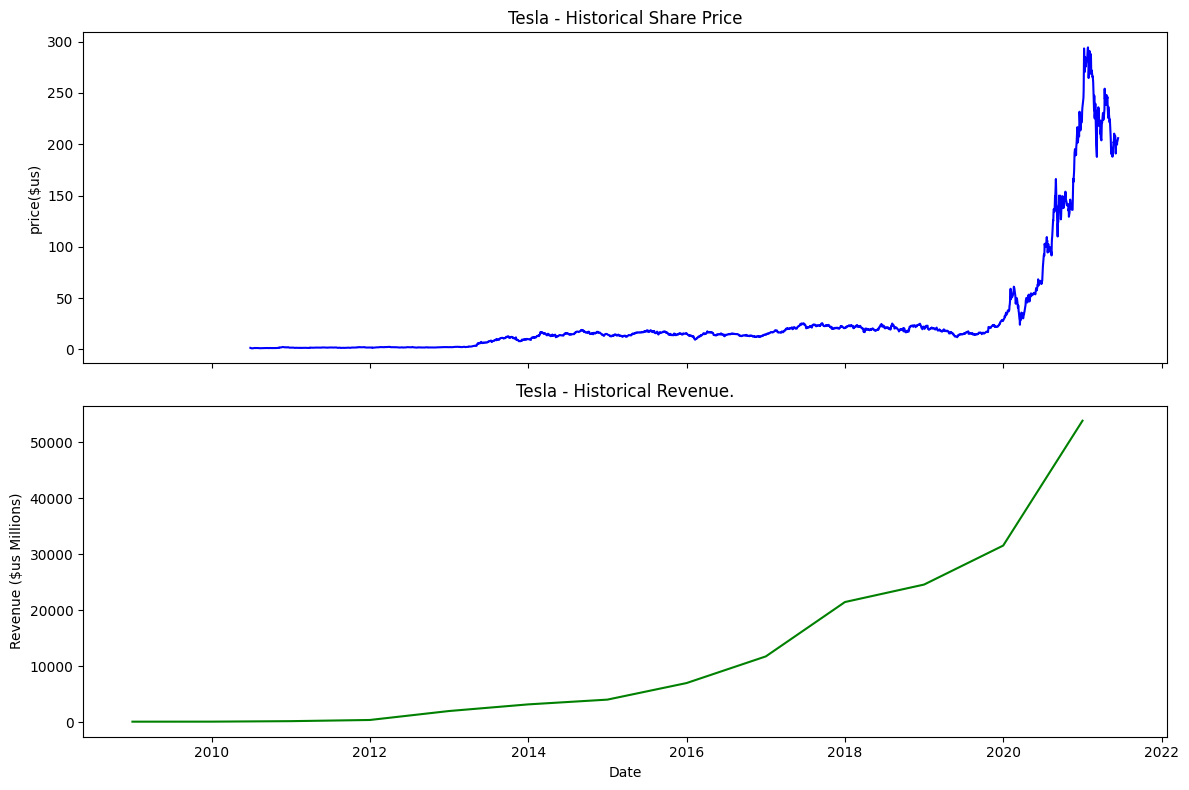

In [66]:
make_graph(tesla_data,tesla_revenue,"Tesla")

## Question 6: Plot GameStop Stock Graph

*Use the `make_graph` function to graph the GameStop Stock Data, also provide a title for the graph. The structure to call the `make_graph` function is `make_graph(gme_data, gme_revenue, 'GameStop')`. Note the graph will only show data upto June 2021.*

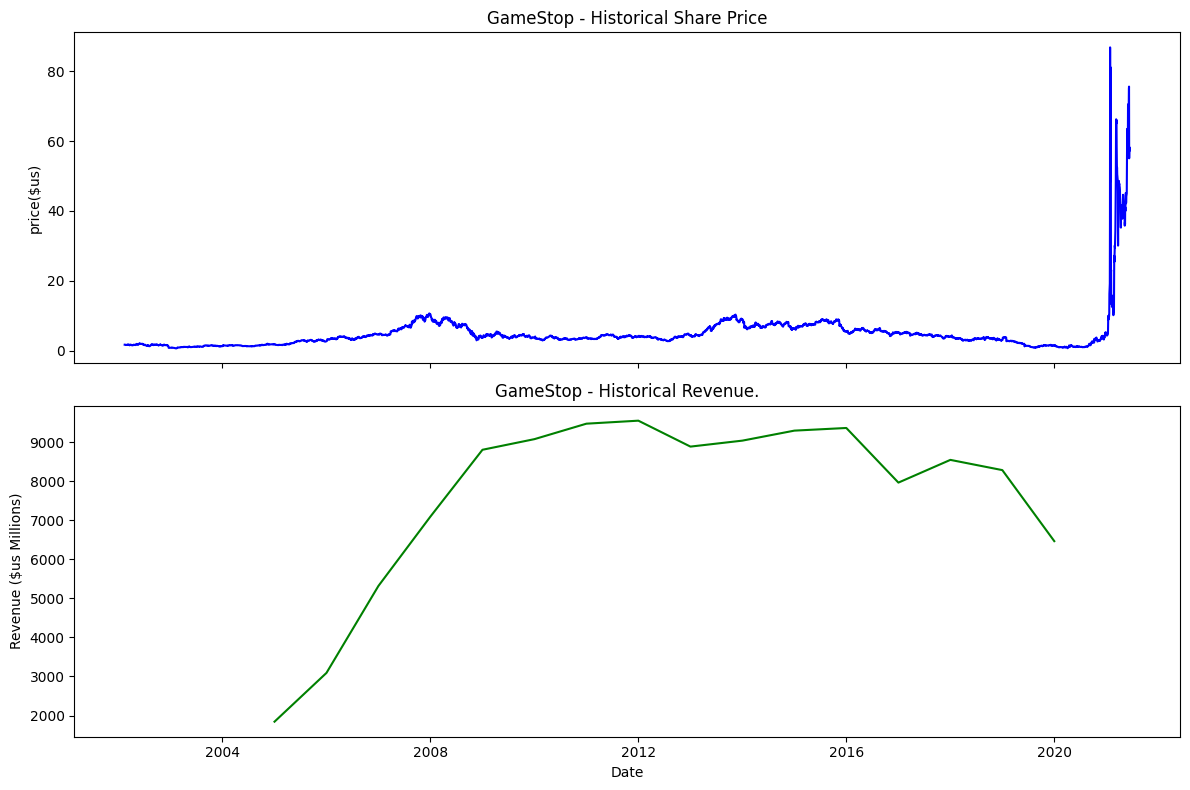

In [69]:
make_graph(gme_data, gme_revenue, "GameStop")